In [6]:
import pandas as pd

df = pd.read_csv("e_nose_thrips_60rep_per_treat_time.csv")   


In [7]:
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(4410000, 15)
['SampleID', 'Time_s', 'Phase', 'Treatment', 'Time_h', 'Replicate', 'TGS2600', 'TGS2602', 'TGS822', 'MQ3', 'MQ135', 'MQ138', 'MiCS_NO2', 'MiCS_NH3', 'MiCS_CO']
  SampleID  Time_s     Phase Treatment  Time_h  Replicate   TGS2600   TGS2602  \
0   S00001     0.0  baseline   Control       1          1  0.987462  1.046710   
1   S00001     0.1  baseline   Control       1          1  0.978447  1.063362   
2   S00001     0.2  baseline   Control       1          1  0.973109  1.092846   
3   S00001     0.3  baseline   Control       1          1  0.978708  1.046065   
4   S00001     0.4  baseline   Control       1          1  0.973937  1.059505   

     TGS822       MQ3     MQ135     MQ138  MiCS_NO2  MiCS_NH3   MiCS_CO  
0  0.894448  0.857001  0.953795  0.971799  0.025356  0.049002  0.633723  
1  0.896456  0.858253  0.940356  0.938666  0.024441  0.047108  0.624540  
2  0.895105  0.860507  0.928988  0.953411  0.023780  0.050842  0.668635  
3  0.882943  0.849374  0.921942  0.958022  

In [9]:
print(df["Treatment"].unique())
print(df["Phase"].unique())
print(df.groupby(["Treatment", "Time_h"]).size())

['Control' 'Low' 'Medium' 'High' 'Mechanical']
['baseline' 'acquisition' 'recovery']
Treatment   Time_h
Control     1         126000
            3         126000
            6         126000
            12        126000
            24        126000
            48        126000
            168       126000
High        1         126000
            3         126000
            6         126000
            12        126000
            24        126000
            48        126000
            168       126000
Low         1         126000
            3         126000
            6         126000
            12        126000
            24        126000
            48        126000
            168       126000
Mechanical  1         126000
            3         126000
            6         126000
            12        126000
            24        126000
            48        126000
            168       126000
Medium      1         126000
            3         126000
            6         1260

Treatment
Control       882000
Low           882000
Medium        882000
High          882000
Mechanical    882000
Name: count, dtype: int64
Phase
acquisition    2520000
recovery       1260000
baseline        630000
Name: count, dtype: int64

Class distribution:
Treatment
Control    882000
Low        882000
Medium     882000
High       882000
Name: count, dtype: int64

Training model...
Training finished.

Accuracy: 0.7797619047619048

Classification report:
              precision    recall  f1-score   support

           0       0.56      0.35      0.43       240
           1       0.82      0.92      0.86       768

    accuracy                           0.78      1008
   macro avg       0.69      0.63      0.65      1008
weighted avg       0.76      0.78      0.76      1008


Confusion matrix:
[[ 83 157]
 [ 65 703]]

ROC-AUC: 0.7533528645833333

Detection times:
     SampleID Treatment  Detection_Time_h
0      S00001   Control               NaN
1      S00002   Control              

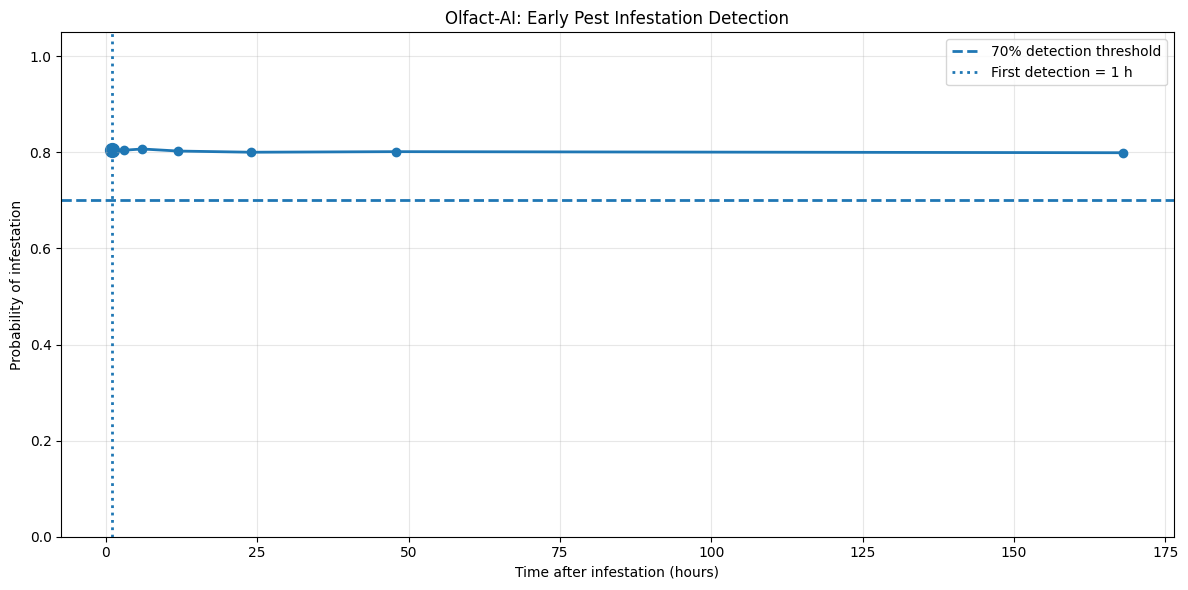

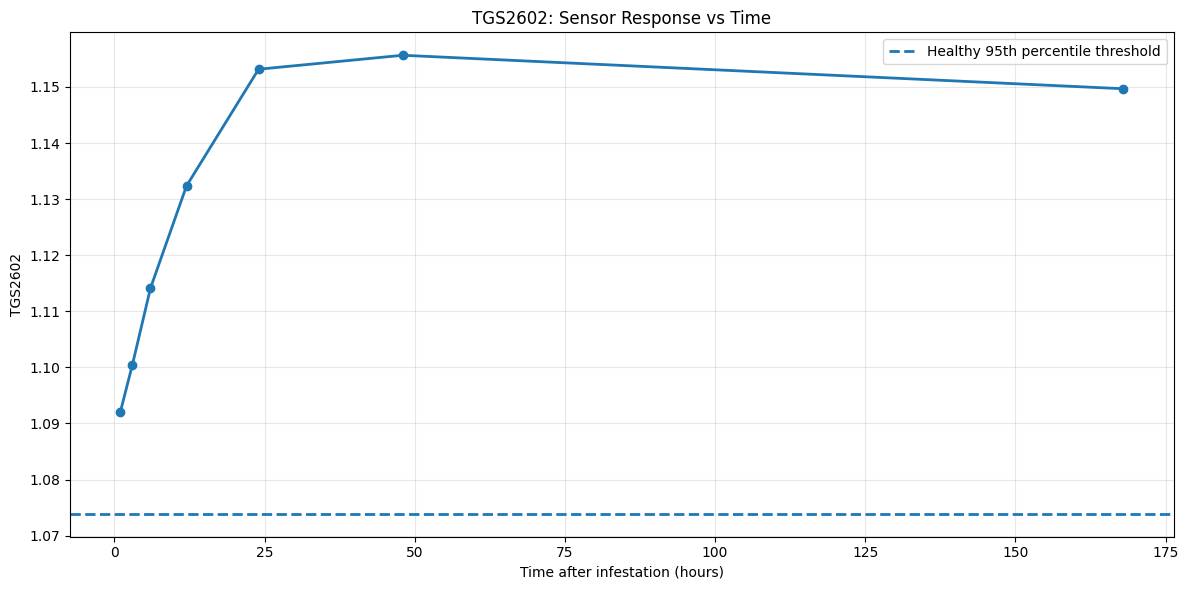

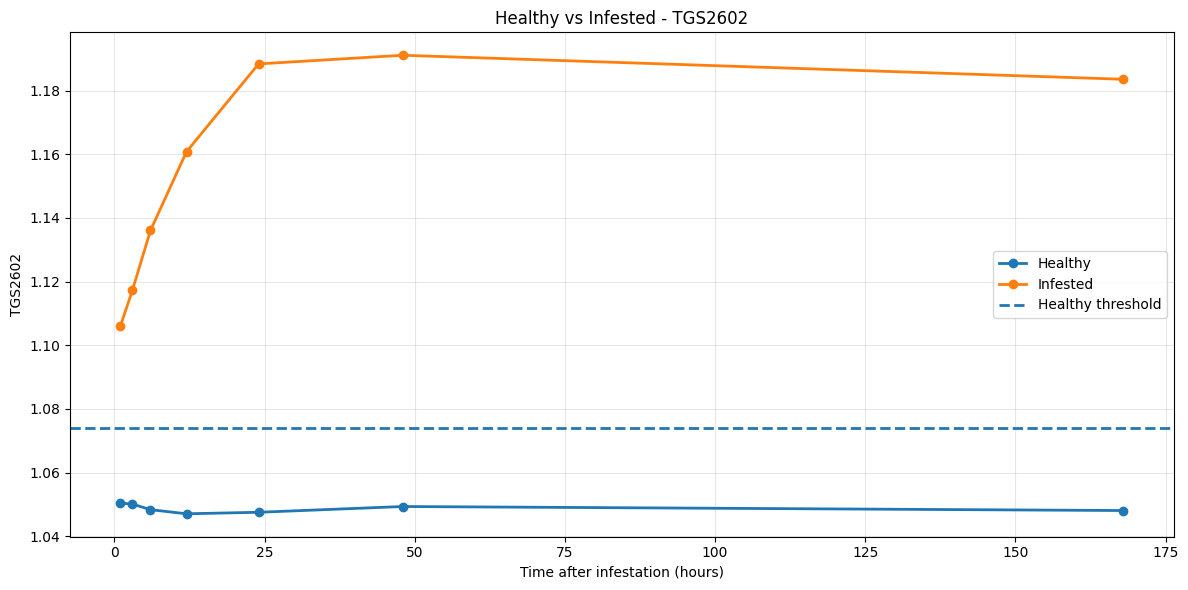


Results saved.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv("data.csv")

ID_COL = "SampleID"
TIME_COL = "Time_s"
TIME_H_COL = "Time_h"
PHASE_COL = "Phase"
LABEL_COL = "Treatment"

SENSORS = [
    "TGS2600",
    "TGS2602",
    "TGS822",
    "MQ3",
    "MQ135",
    "MQ138",
    "MiCS_NO2",
    "MiCS_NH3",
    "MiCS_CO"
]

df = df.dropna(
    subset=SENSORS + [
        ID_COL,
        TIME_H_COL,
        LABEL_COL
    ]
).copy()

for col in SENSORS:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.dropna(
    subset=SENSORS
).copy()

df = df.sort_values(
    [ID_COL, TIME_H_COL, PHASE_COL, TIME_COL]
).reset_index(drop=True)

print(df[LABEL_COL].value_counts())
print(df[PHASE_COL].value_counts())


df["infected"] = np.nan

df.loc[
    df[LABEL_COL] == "Control",
    "infected"
] = 0

df.loc[
    df[LABEL_COL].isin(
        ["Low", "Medium", "High"]
    ),
    "infected"
] = 1

df_model = df[
    df[LABEL_COL].isin(
        ["Control", "Low", "Medium", "High"]
    )
].copy()

df_model["infected"] = (
    df_model["infected"]
    .astype(int)
)

print(
    "\nClass distribution:"
)

print(
    df_model[
        LABEL_COL
    ].value_counts()
)


feature_frames = []

GROUP_COLUMNS = [
    ID_COL,
    TIME_H_COL,
    PHASE_COL
]

for sensor in SENSORS:

    temp = (
        df_model
        .groupby(GROUP_COLUMNS)[sensor]
        .agg([
            "mean",
            "std",
            "min",
            "max"
        ])
        .reset_index()
    )

    temp = temp.rename(
        columns={
            "mean": f"{sensor}_mean",
            "std": f"{sensor}_std",
            "min": f"{sensor}_min",
            "max": f"{sensor}_max"
        }
    )

    feature_frames.append(temp)


features = feature_frames[0]

for temp in feature_frames[1:]:

    features = features.merge(
        temp,
        on=GROUP_COLUMNS,
        how="inner"
    )


metadata = (
    df_model[
        GROUP_COLUMNS +
        [LABEL_COL, "infected"]
    ]
    .drop_duplicates(
        subset=GROUP_COLUMNS
    )
)

features = features.merge(
    metadata,
    on=GROUP_COLUMNS,
    how="inner"
)

features = features.fillna(0)

FEATURE_COLUMNS = [
    col
    for col in features.columns
    if col not in [
        ID_COL,
        TIME_H_COL,
        PHASE_COL,
        LABEL_COL,
        "infected"
    ]
]

X = features[FEATURE_COLUMNS]

y = features["infected"]

groups = features[ID_COL]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining model...")

model.fit(
    X_train,
    y_train
)

print("Training finished.")


y_pred = model.predict(
    X_test
)

y_prob = model.predict_proba(
    X_test
)[:, 1]

print(
    "\nAccuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "\nClassification report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "\nConfusion matrix:"
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

try:

    print(
        "\nROC-AUC:",
        roc_auc_score(
            y_test,
            y_prob
        )
    )

except:
    pass


features[
    "infection_probability"
] = model.predict_proba(
    features[FEATURE_COLUMNS]
)[:, 1]


PROBABILITY_THRESHOLD = 0.70

features[
    "above_threshold"
] = (
    features[
        "infection_probability"
    ]
    >= PROBABILITY_THRESHOLD
)


def detection_time(group):

    group = group.sort_values(
        TIME_H_COL
    ).copy()

    group = group[
        group[PHASE_COL] == "acquisition"
    ]

    condition = (
        group[
            "infection_probability"
        ]
        >= PROBABILITY_THRESHOLD
    )

    rolling = (
        condition
        .astype(int)
        .rolling(2)
        .sum()
    )

    indices = np.where(
        rolling >= 2
    )[0]

    if len(indices) == 0:
        return np.nan

    return group.iloc[
        indices[0]
    ][TIME_H_COL]


detection_results = []

for sample_id, group in features.groupby(
    ID_COL
):

    t = detection_time(
        group
    )

    treatment = group[
        LABEL_COL
    ].iloc[0]

    detection_results.append({

        "SampleID": sample_id,

        "Treatment": treatment,

        "Detection_Time_h": t

    })


detection_df = pd.DataFrame(
    detection_results
)

print(
    "\nDetection times:"
)

print(
    detection_df
)


valid_times = (
    detection_df[
        detection_df["Treatment"] != "Control"
    ]["Detection_Time_h"]
    .dropna()
)


if len(valid_times) > 0:

    print(
        "\nMean detection time:",
        valid_times.mean(),
        "hours"
    )

    print(
        "Median detection time:",
        valid_times.median(),
        "hours"
    )


importance = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLUMNS
).sort_values(
    ascending=False
)

print(
    "\nTop features:"
)

print(
    importance.head(20)
)


sensor_importance = {}

for sensor in SENSORS:

    sensor_importance[
        sensor
    ] = sum(
        importance.get(
            f"{sensor}_{stat}",
            0
        )
        for stat in [
            "mean",
            "std",
            "min",
            "max"
        ]
    )

sensor_importance = pd.Series(
    sensor_importance
).sort_values(
    ascending=False
)

print(
    "\nSensor importance:"
)

print(
    sensor_importance
)


best_sensor = (
    sensor_importance
    .index[0]
)

print(
    "\nMost important sensor:",
    best_sensor
)


healthy_sensor = df_model[
    df_model["infected"] == 0
][best_sensor]

sensor_threshold = np.percentile(
    healthy_sensor,
    95
)

print(
    "\nHealthy sensor threshold:",
    sensor_threshold
)


probability_by_time = (
    features[
        features[PHASE_COL] == "acquisition"
    ]
    .groupby(TIME_H_COL)
    ["infection_probability"]
    .mean()
    .reset_index()
)


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    probability_by_time[
        TIME_H_COL
    ],
    probability_by_time[
        "infection_probability"
    ],
    marker="o",
    linewidth=2
)

plt.axhline(
    PROBABILITY_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="70% detection threshold"
)

crossing = probability_by_time[
    probability_by_time[
        "infection_probability"
    ] >= PROBABILITY_THRESHOLD
]

if len(crossing) > 0:

    first_time = crossing[
        TIME_H_COL
    ].iloc[0]

    plt.axvline(
        first_time,
        linestyle=":",
        linewidth=2,
        label=f"First detection = {first_time} h"
    )

    plt.scatter(
        first_time,
        crossing[
            "infection_probability"
        ].iloc[0],
        s=100
    )


plt.xlabel(
    "Time after infestation (hours)"
)

plt.ylabel(
    "Probability of infestation"
)

plt.title(
    "Olfact-AI: Early Pest Infestation Detection"
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "infection_probability_vs_time.png",
    dpi=300
)

plt.show()


sensor_by_time = (
    df_model
    .groupby(TIME_H_COL)
    [best_sensor]
    .mean()
    .reset_index()
)


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    sensor_by_time[
        TIME_H_COL
    ],
    sensor_by_time[
        best_sensor
    ],
    marker="o",
    linewidth=2
)

plt.axhline(
    sensor_threshold,
    linestyle="--",
    linewidth=2,
    label="Healthy 95th percentile threshold"
)

plt.xlabel(
    "Time after infestation (hours)"
)

plt.ylabel(
    best_sensor
)

plt.title(
    f"{best_sensor}: Sensor Response vs Time"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "sensor_response_vs_time.png",
    dpi=300
)

plt.show()


healthy = (
    df_model[
        df_model["infected"] == 0
    ]
    .groupby(TIME_H_COL)
    [best_sensor]
    .mean()
)

infested = (
    df_model[
        df_model["infected"] == 1
    ]
    .groupby(TIME_H_COL)
    [best_sensor]
    .mean()
)


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    healthy.index,
    healthy.values,
    marker="o",
    linewidth=2,
    label="Healthy"
)

plt.plot(
    infested.index,
    infested.values,
    marker="o",
    linewidth=2,
    label="Infested"
)

plt.axhline(
    sensor_threshold,
    linestyle="--",
    linewidth=2,
    label="Healthy threshold"
)

plt.xlabel(
    "Time after infestation (hours)"
)

plt.ylabel(
    best_sensor
)

plt.title(
    f"Healthy vs Infested - {best_sensor}"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "healthy_vs_infested.png",
    dpi=300
)

plt.show()


features.to_csv(
    "olfact_ai_predictions.csv",
    index=False
)

detection_df.to_csv(
    "olfact_ai_detection_times.csv",
    index=False
)

importance.to_csv(
    "olfact_ai_feature_importance.csv"
)

print(
    "\nResults saved."
)